# Método de Monte Carlo

*Referências*

Este material foi desenvolvido a partir dos conceitos estudados no curso de extensão:

- Estatística e Probabilidade - ICMC/USP

O conteúdo foi reorganizado, interpretado e complementado com exemplos práticos, simulações e conexões com Machine Learning.

<hr>

A simulação de Monte Carlo utiliza **amostragem aleatória** para resolver problemas matemáticos complexos, especialmente quando soluções analíticas são difíceis ou impossíveis.

A ideia central é transformar um problema determinístico em um problema probabilístico:

$$
\text{Problema difícil} \rightarrow \text{Simulação aleatória} \rightarrow \text{Estimativa}
$$

*Um dos métodos mais populares para simular processos probabilísticos foi proposto por na década de 40 por Stanislaw Ulam, que estava trabalhando no desenvolvimento da bomba atômica, no Los Alamos National Laboratory, nos Estados Unidos. Uma método parecido havia sido proposto por Enrico Fermi no estudo de difusão de neutrons, mas ele não publicou a ideia. A patir do trabalho de Ulam, John von Neumann adaptou o método e programou o  ENIAC (Electronic Numerical Integrator and Computer), que foi o primeiro computador programável, de forma geral, da história. John von Neumann chamou o método de Método de Monte Carlo, que, basicamente, é usado para gerar números aleatórios a partir de uma certa distribuição de probabilidades. O nome se deve à cidade de Monte Carlo, no principado de Mônaco, que possui diversos cassinos. O método de Monte Carlo possui as mais diversas aplicações que vão desde o estudo de emissões nucleares até inferência Bayesiana, sendo, nesse caso, é usada uma adaptação do método chamada Markov Chain Monte Carlo (MCMC).*


## Geração de números aleatórios

O primeiro passo na simulação de processos estocásticos é a geração de números aleatórios, ou seja, gerar números no intervalo [0,1] onde todos os valores tem a mesma chance de ocorrerem. 

No método chamada Linear Congruential Generator, nós geramos uma sequência de números pseudo-aleatórios através da relação de recorrência:
$$X_{n+1} = (aX_n + c) \mod m$$
onde $X_0$ é a semente, m, a e c são inteiros maiores do que zero. A sequência obtida satisfaz  $0 \leq X_i \leq m$. Para gerar o número no intervalo [0,1], usamos $$U_n = X_n/m.$$
Vamos considerar uma exemplo.

[1, 11, 9, 3, 1, 11, 9, 3, 1, 11, 9, 3, 1, 11, 9, 3, 1, 11, 9, 3, 1]


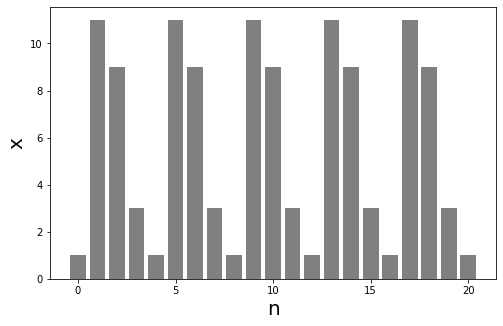

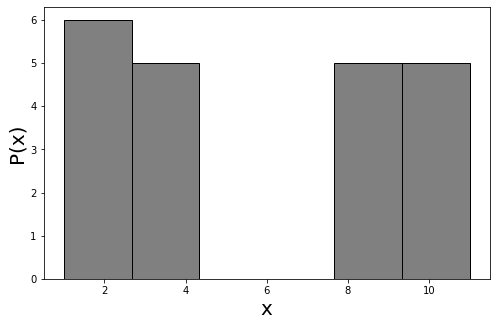

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# função para gerar os números aleatórios
def random(Xi, a, c, m):
    Xii = (a*Xi + c)%m
    return Xii

# constantes
a = 11; c = 0; m = 16
X0 = 1 # semente do gerador
n = 20 # quantidade de números a serem gerados
Xi = X0 # inicia a sequência de números
X = [X0] # armazena os números gerados
for i in range(n):
    Xi = random(Xi,a,c,m)
    X.append(Xi)
print(X)
# mostra a sequência gerada
s = np.arange(0, len(X))
plt.figure(figsize=(8,5))
plt.bar(s,X, color = 'gray')
plt.xlabel('n', fontsize = 20)
plt.ylabel('x',fontsize = 20)
plt.savefig('MC1.svg')
plt.show(True)
# mostra o histograma da sequência gerada
plt.figure(figsize=(8,5))
plt.hist(X, bins='auto', color = 'gray',
         histtype='bar', ec='black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)',fontsize = 20)
plt.savefig('MC2.svg')
plt.show(True)

Notamos que a sequência é periódica, sendo que $[1, 11, 9, 3]$ se repete. Ou seja, não temos um bom gerador de números aleatórios, pois podemos prever o próximo número se descobrir a sequência. Para resolver esse problema, temos o seguinte teorema, demonstrado no livro The Art Of Computer Programming (Donald Knuth).

O gerador pseudo-aleatório linear produz uma sequência aperiódica se as seguintes condições forem sastisfeitas:
* $X_{n+1} = (aX_n + c)\mod m, \quad U_n = X_n/m.$<br>
* Se $q$ é um número primo que divide $m$, então ele divide $b=a-1$.<br>
* Se $m$ é múltiplo de 4, então $b=a-1$ deve ser múltiplo de 4.<br>
* O único inteiro que divide exatamente $m$ e $c$ é  valor um.<br>

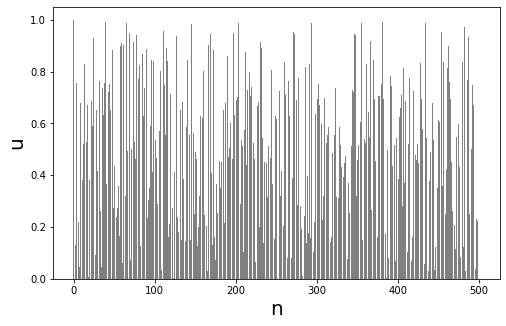

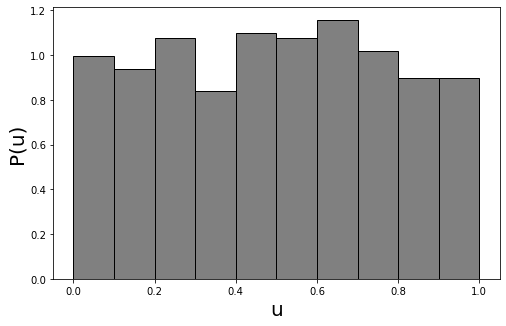

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# função que gera os números aleatórios
def random(Xi, a, c, m):
    Xii = (a*Xi + c)%m
    return Xii

# constantes
a = 7**5; c = 0; m = 2**31 - 1
X0 = 1 # semente do gerador
n = 500 # quantidade de números a serem gerados
Xi = 1 # inicia sequência
X = [X0] # armazena os números gerados
for i in range(n):
    Xi = random(Xi,a,c,m)
    X.append(Xi/m)
# mostra a sequência gerada
s = np.arange(0, len(X))
plt.figure(figsize=(8,5))
plt.bar(s,X, color = 'gray')
plt.xlabel('n', fontsize = 20)
plt.ylabel('u',fontsize = 20)
plt.savefig('MC3.svg')
plt.show(True)
# mostra o histograma da sequência gerada
plt.figure(figsize=(8,5))
plt.hist(X, bins='auto', color = 'gray',
         histtype='bar', ec='black',density='True')
plt.xlabel('u', fontsize = 20)
plt.ylabel('P(u)',fontsize = 20)
plt.savefig('MC4.svg')
plt.show(True)

Vemos que agora a frequência em que os números ocorrem é praticamente a mesma.

## Retirando uma bola de uma urna

Para começarmos a enteder a simulação de processos estocásticos, vamos simular a retirada de uma bola de uma urna com reposição, ou seja, a bola retirada é sempre recolocada na urna antes da próxima retirada.

Vamos supor que temos uma urna com 6 bolas brancas e 4 pretas:

In [ ]:
urna = ['B','B','B','B','B','B','P','P','P','P']
print('Urna:',urna)

Urna: ['B', 'B', 'B', 'B', 'B', 'B', 'P', 'P', 'P', 'P']


Para selecinarmos uma bola, basta selecionarmos uma posição no vetor e verificar a respectiva bola. Vamos fazer essa retirada 100 vezes e verificar quantas vezes retiramos uma bola branca.

In [ ]:
import random # biblioteca para gerar números aleatórios
n = 0 # numero de retiradas de bolas brancas
nsim = 1000 # numero de experimentos
for i in range(0,nsim):
    posicao = random.randint(0,len(urna)-1)
    if(urna[posicao] == 'B'):
        n = n + 1
print('Fração de vezes que saiu uma bola branca:', n/nsim)

Fração de vezes que saiu uma bola branca: 0.573


In [ ]:
# vamos calcular o valor teórica da probabilidade contanto o número de bolas brancas na urna
valor_teorico = 0
for bola in urna:
    if (bola == 'B'):
        valor_teorico = valor_teorico + 1
valor_teorico = valor_teorico/len(urna)
print('Valor teórico da probabilidade:', valor_teorico)

Valor teórico da probabilidade: 0.6


Ou seja, vemos que é próximo do valor teórico: 6/10. Se aumentarmos o número de experimentos, vamos mostrar os resultados em um gráfico.

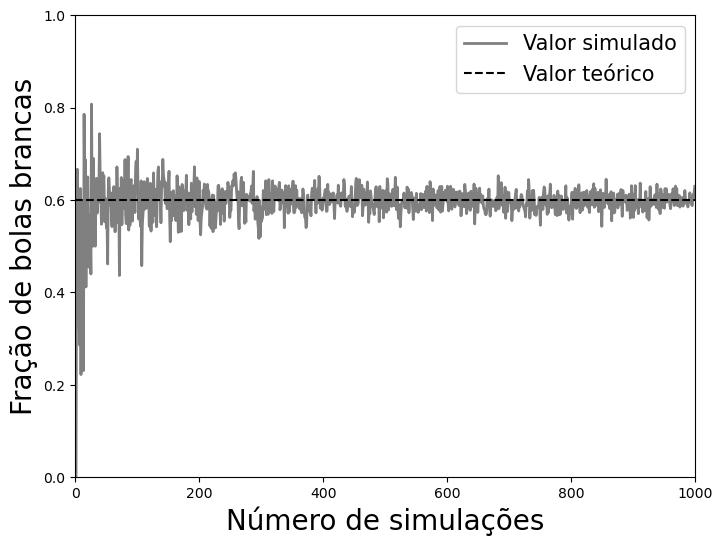

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as random
# inicia a semente do gerador aleatório
np.random.seed(10)

# urna com 6 bolas brancas (B) e 4 pretas (P)
#urna = ['B','B','B','B','B','B','P','P','P','P']
urna = ['P','P','B','P','B','B','B','B','P','B']
p = 0.6 # probabilidade teórica
vp = [] # lista que armazena a fração de ocorrências
vsim = [] # armazena o número de simulações
Nmax = 1000 # numero máximo de simulações
for nsim in np.arange(1,Nmax,1):
    n = 0 # número bolas brancas retiradas
    for i in range(1,nsim):
        # sorteia uma bola
        bola = random.choice(urna)
        if(bola == 'B'):
            n = n + 1
    vp.append(n/nsim)
    vsim.append(nsim)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vsim, vp, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=p, color='black', linestyle='--',
            label = 'Valor teórico')
plt.ylabel("Fração de bolas brancas", fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.xlim([0.0, Nmax])
plt.ylim([0.0, 1.0])
plt.legend(fontsize=15)
plt.savefig('sim1.svg')
plt.show(True)

Usando a distribuição uniforme para selecionar as bolas:

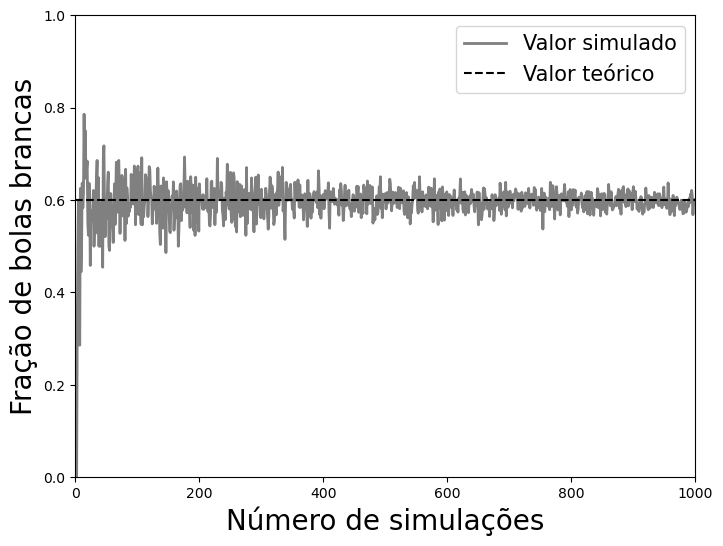

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
# inicia a semente do gerador aleatório
np.random.seed(10)

vp = [] # lista que armazena a fração de ocorrências
vsim = [] # armazena o número de simulações
Nmax = 1000 # numero máximo de simulações
p = 0.6 # probabilidade de sair uma bola branca
for nsim in np.arange(1,Nmax,1):
    n = 0 # número de bolas brancas retiradas
    for i in range(1,nsim):
        if(np.random.uniform(0,1)<p):
            # se o valor sorteado é menor do que p
            n = n + 1
    vp.append(n/nsim)
    vsim.append(nsim)

plt.figure(figsize=(8,6))
plt.plot(vsim, vp, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=p, color='black', linestyle='--',
            label = 'Valor teórico')
plt.ylabel("Fração de bolas brancas", fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.xlim([0.0, Nmax])
plt.ylim([0.0, 1.0])
plt.legend(fontsize=15)
plt.savefig('sim1.svg')
plt.show(True)

Ou seja, vemos que o valor converge para a probabilide esperada.

> **Exercício**: Considere agora uma urna com 14 bolas brancas e 6 pretas. Repita o procedimento acima e verifique se a estimação é correta.

## Lançando uma moeda

Vamos simular o lançamento de uma moeda. Para isso, precisamos definir uma regra para escolher se saiu cara ou coroa. Para entendermos melhor como definir essa regra, notem que no exemplo anterior, ordenamos as bolas em um vetor. Essa ordenação não faz a menor diferença no exemplo anterior, pois a não consideramos. Se consideramos a ordenação, a regra poderia ser: se a posição no vetor é menor ou igual a 6, então a bola é branca. Caso contrário, é preta. Ou seja, podemos usar essa regra para definir qual dos valores vamos selecionar.

No caso de uma moeda, vamos supor que $p$ é a chance de sair cara. Então, a regra pode ser: se o número sorteado em [0,1] for menor do que $p$, então saiu cara. Caso contrário, saiu coroa. Vamos realizar um exmperimento.

In [ ]:
p = 0.6 # probabilidade de sair cara

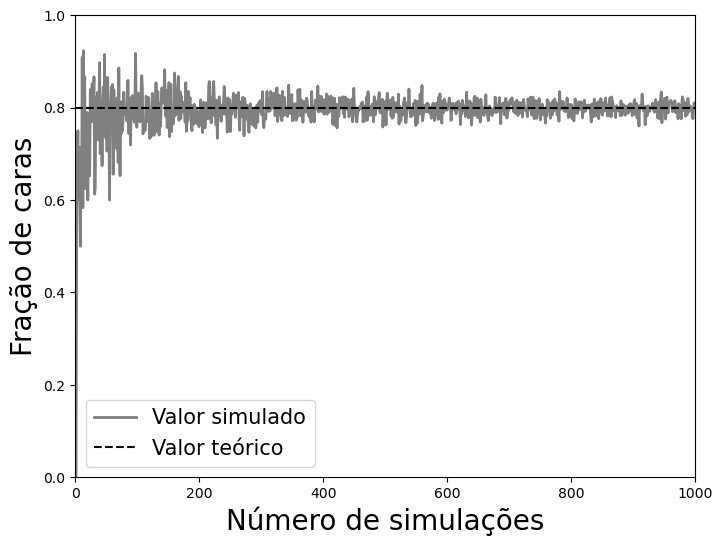

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

p = 0.8 # probabilidade de sair cara
vp = [] # lista que armazena a fração de ocorrências
vsim = [] # armazena o número de simulações
Nmax = 1000 # número máximo de simulações
for nsim in np.arange(1,Nmax,1):
    nhead = 0 # número de caras
    for i in range(1,nsim):
        # se o valor sorteado é menor do que p
        if(np.random.uniform() <= p):
            # sai uma cara
            nhead = nhead + 1
    vp.append(nhead/nsim)
    vsim.append(nsim)
#mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vsim, vp, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=p, color='black', linestyle='--',
            label = 'Valor teórico')
plt.ylabel("Fração de caras", fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.xlim([0.0, Nmax])
plt.ylim([0.0, 1.0])
plt.legend(fontsize = 15)
plt.savefig('sim2.svg')
plt.show(True)

> **Exercício**: Varie a probabilidade de sair cara e verifique como muda o gráfico acima.

## Calculando o valor de $\pi$

Para calcular o valor e $\pi$, vamos considerar um quadrado de raio 2R que contém um círculo de raio R, conforme a figura abaixo.

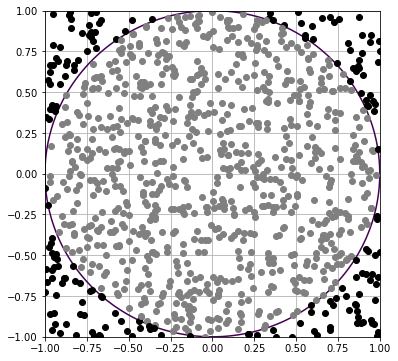

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 1
x = np.linspace(-R, R, 100)
y = np.linspace(-R, R, 100)
X, Y = np.meshgrid(x,y)
F = X**2 + Y**2 - 1
plt.figure(figsize=(6,6))
plt.contour(X,Y,F,[0])
plt.grid(True)

# Seleciona pontos aleatórios
for i in range(0,1000):
    x = np.random.uniform(-1,1)
    y = np.random.uniform(-1,1)
    if(x**2 + y**2 < R**2):
        plt.plot(x,y,'o', color="gray")
    else:
        plt.plot(x,y,'o', color="black")
plt.savefig("pi1.svg")
plt.show()

Selecionando posições aleatórias nessa região e incluindo pontos, conforme exemplificado na figura, temos que alguns pontos caem dentro do círculo (pontos vermelhos), enquanto que outros ficam fora (pontos em azul). Inserindo um grande número de pontos de forma aleatória, temos que:<br>
**o número de pontos dentro do círculo/número de pontos gerados = área do círculo/área do quadrado.**<br>
Ou seja, o valor de $\pi$:<br>
o número de pontos dentro do círculo/número de pontos gerados = $\pi R^2$/$4R^2$<br>
Logo:<br>
$\pi$ = 4* o número de pontos dentro do círculo/ número de pontos gerados

In [ ]:
n = 5000
count_inside = 0
for i in np.arange(0,n):
    x = np.random.uniform(-1,1)
    y = np.random.uniform(-1,1)
    if( x**2 + y**2 < 1):
        count_inside = count_inside + 1
pi = 4*count_inside/n
print("Value of pi:", pi)

Value of pi: 3.1792


Podemos analisar como essa aproximação muda com o número de pontos gerados.

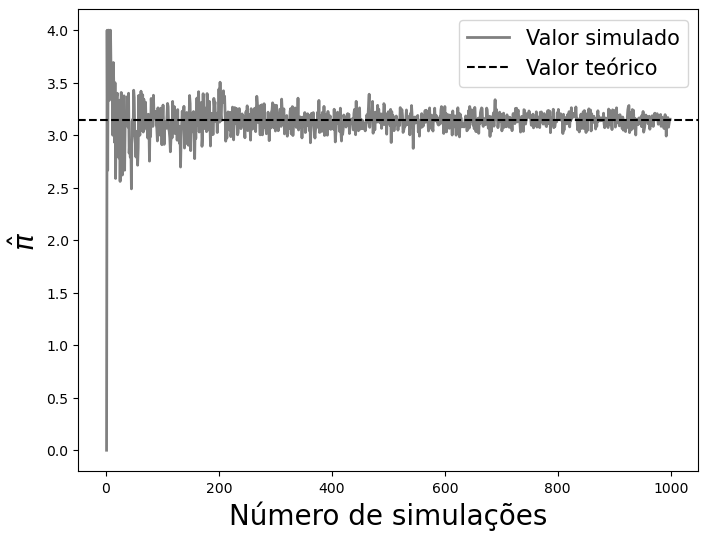

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# inicia a semente do gerador aleatório
np.random.seed(10)

N = 1000 # número de pontos gerados
vpi = [] # armazena o valor estimado de pi
vn = [] # armaze o número de simulações
R = 1 # raio do círculo
for n in np.arange(1,N, 1):
    count_inside = 0
    for i in np.arange(0,n):
        # sorteia dois valores em [-1,1]
        x = np.random.uniform(-1,1)
        y = np.random.uniform(-1,1)
        # verifica se está dentro do círculo
        if(x**2 + y**2 < R**2):
            count_inside = count_inside + 1
    pi = 4*count_inside/n # calcula pi
    vpi.append(np.mean(pi))
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vn, vpi, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=np.pi, color='black', linestyle='--',
            label = 'Valor teórico')
plt.ylabel(r'$\hat{\pi}$', fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.legend(fontsize = 15)
plt.savefig('pi2.svg')
plt.show(True)

> **Exercício:** Verifique quantas simulações são necessárias para você obter um valor que seja 99% próximo de $\pi$. Dica: use o valor conhecido de $\pi$ e faça um gráfico da diferença entre o valor obtido e o real em função do número de pontos sorteados.

## Semente do gerador de número aleatórios

Notem que a semente gera uma sequência de número aleatórios e a sequência se repete quando reiniciamos a semente.

In [ ]:
import numpy as np
print("Primeira sequencia:")
np.random.seed(123)
for i in np.arange(0,10):
    n = np.random.uniform()
    print(n)
print('\n')

print("Segunda sequencia:")
np.random.seed(123)
for i in np.arange(0,10):
    n = np.random.uniform()
    print(n)

Primeira sequencia:
0.6964691855978616
0.28613933495037946
0.2268514535642031
0.5513147690828912
0.7194689697855631
0.42310646012446096
0.9807641983846155
0.6848297385848633
0.48093190148436094
0.3921175181941505


Segunda sequencia:
0.6964691855978616
0.28613933495037946
0.2268514535642031
0.5513147690828912
0.7194689697855631
0.42310646012446096
0.9807641983846155
0.6848297385848633
0.48093190148436094
0.3921175181941505


Se não reinicarmos a semente:

In [ ]:
import numpy as np
print("Primeira sequencia:")
np.random.seed(123)
for i in np.arange(0,10):
    n = np.random.uniform()
    print(n)
print('\n')

print("Segunda sequencia:")
for i in np.arange(0,10):
    n = np.random.uniform()
    print(n)

Primeira sequencia:
0.6964691855978616
0.28613933495037946
0.2268514535642031
0.5513147690828912
0.7194689697855631
0.42310646012446096
0.9807641983846155
0.6848297385848633
0.48093190148436094
0.3921175181941505


Segunda sequencia:
0.3431780161508694
0.7290497073840416
0.4385722446796244
0.05967789660956835
0.3980442553304314
0.7379954057320357
0.18249173045349998
0.17545175614749253
0.5315513738418384
0.5318275870968661


> **Para pensar:** Como você verificaria se esse números gerados são realmente aleatórios?

## Calculando integrais

Podemos calcular integrais numericamente usando números aleatórios. Temos:<br>
$\theta = \int_{0}^{1} g(u)du = \int_{0}^{1} 1\cdot g(u)du = \int_{0}^{1} f(u) g(u)du = E[g(U)]$<br>
onde $U$ tem distribuição uniforme em $[0,1]$:<br>
\begin{equation}
f(u) =
\begin{cases}
1, \quad 0 \leq u \leq 1\\
0 \quad \mbox{caso contrário}.
\end{cases}
\end{equation}

Assim, podemos calcular $\theta$ numericamente:<br>
$\lim_{n \rightarrow \infty} \sum_{i=1}^{n}\frac{g(U_i)}{n} = E[g(U)] = \theta$

Vamos considerar um exemplo: $\theta = \int_{0}^{1}(x+1)dx = 1.5$

In [ ]:
import numpy as np
# função a ser integrada
def g(x):
    f = x + 1
    return f
n = 1000 # número de valores sorteados
theta = 0
for i in range(n):
    # sorteia um valor uniformemente em [0,1]
    u = np.random.uniform(0,1)
    theta = theta + g(u)
# calcula a média de theta
theta = theta/n
print("Integral: ", theta)

Integral:  1.4996329637345225


Podemos verificar como o valor obtido varia com o número de simulações:

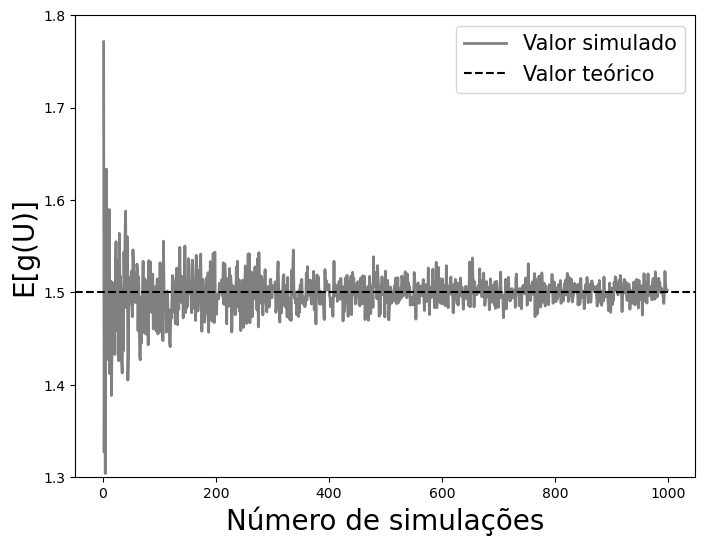

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)

# função a ser integrada
def g(x):
    f = x + 1
    return f

valor_teorico = 1.5
Nmax = 1000 # número máximo de simulações
vtheta = []
vn = []
for n in range(1,Nmax):
    theta = 0 # valor da integral a ser estimado
    for i in range(n):
        # sorteia um valor em [0,1]
        u = np.random.uniform(0,1)
        theta = theta + g(u)
    # calcula o valor médio de theta
    theta = theta/n
    vtheta.append(theta)
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vn, vtheta, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=valor_teorico, color='black',
            linestyle='--', label = 'Valor teórico')
plt.ylabel('E[g(U)]', fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.legend(fontsize = 15)
plt.ylim(1.3,1.8)
plt.savefig("Int1.svg")
plt.show(True)

No caso geral, temos as seguinte integral:<br>
$\theta = \int_{a}^{b} g(u) du$ <br>
se fizermos $y = \frac{u-a}{b-a}$, temos $du = (b-a)dy$<br>
Assim,
$\theta = \int_{a}^{b} g(u) du = \int_{0}^{1} g[(b-a)y + a](b-a) dy = \int_{0}^{1} h(y) dy$, <br>
onde $h(y) = (b-a)g[(b-a)y + a]$. <br>
$\theta = E[h(Y)]$.

Vamos considerar um exemplo: <br>
$\theta = \int_{2}^{4}(x+1)dx = 8$

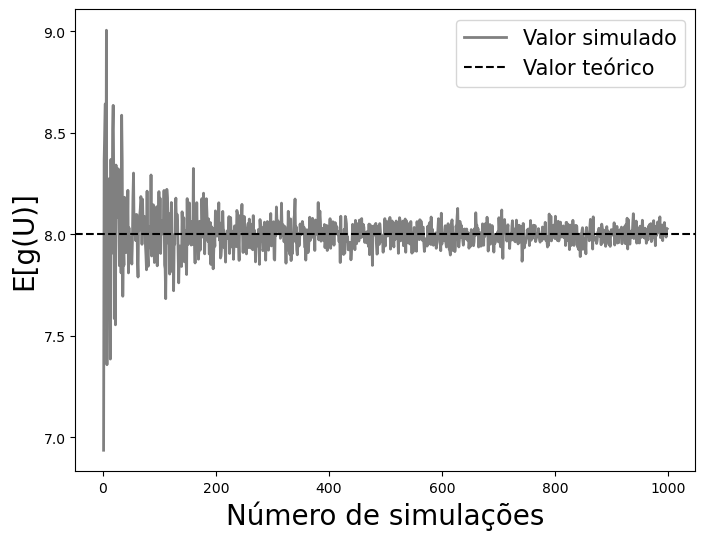

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# função a ser integrada
def g(x):
    g = x + 1
    return g

def h(y,a,b):
    val = (b-a)*g(a+(b-a)*y)
    return val

valor_teorico = 8
a = 2; b = 4 # limites de integração
Nmax = 1000 # número máximo de simulacoes
vtheta = []
vn = []
for n in range(1,Nmax):
    theta = 0
    for i in range(n):
        u = np.random.uniform(0,1)
        # calcula theta
        theta = theta + h(u,a,b)
    # calcula o valor médio de theta
    theta = theta/n
    vtheta.append(theta)
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vn, vtheta, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=valor_teorico, color='black',
            linestyle='--', label = 'Valor teórico')
plt.ylabel('E[g(U)]', fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.legend(fontsize = 15)
plt.savefig("Int2.svg")
plt.show(True)

No caso em que um dos limites de integração é infinito, procedemos da seguinte maneira:
<br>
$\theta = \int_{0}^{\infty} g(u) du$ <br>
definindo: $y = 1/(x+1)$ temos $dy = y^2 dx$. Thus <br>
$\theta = \int_{0}^{\infty} g(u) du = \int_{0}^{1}g(\frac{1}{y} - 1)\frac{dy}{y^2} = \int_{0}^{1}h(y)dy$<br>
onde<br>
$h(y) = \frac{g(1/y-1)}{y^2}$<br>
$\theta = E[h(Y)]$.

Vamos calcular:<br>
$\theta = \int_{0}^{\infty} e^{-x}dx = 1$

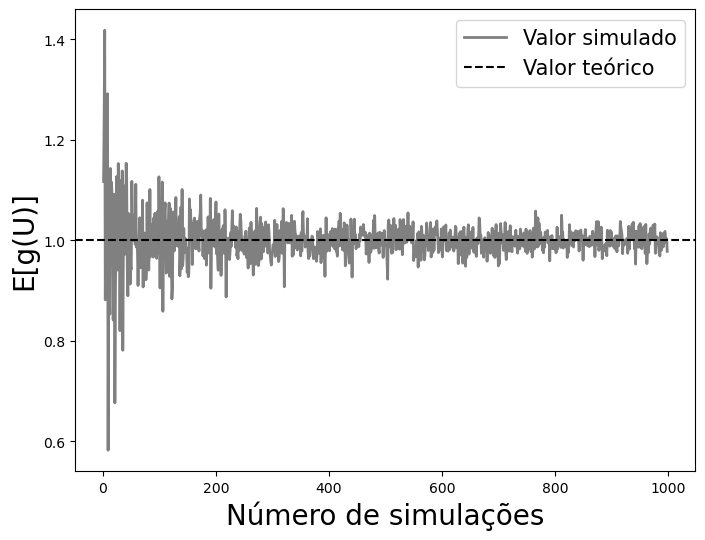

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# função a ser integrada
def g(x):
    f = np.exp(-x)
    return f

def h(y):
    val = g(1/y -1)/y**2
    return val

valor_teorico = 1
Nmax = 1000 # número máximo de simulações
vtheta = []
vn = []
# realiza a simulação
for n in range(1,Nmax):
    theta = 0
    for i in range(n):
        u = np.random.uniform(0,1)
        # calcula theta
        theta = theta + h(u)
    # calcula o valor médio de theta
    theta = theta/n
    vtheta.append(theta)
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vn, vtheta, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=valor_teorico, color='black',
            linestyle='--', label = 'Valor teórico')
plt.ylabel('E[g(U)]', fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.legend(fontsize = 15)
plt.savefig("int3.svg")
plt.show(True)

## Integrais múltiplas

Exemplo: Calcule a integral a seguir usando números aleatórios.
$$
\theta = \int_0^2 \int_1^2 \left(\frac{x^2y}{3} + y^2\right)dydx = 6
$$


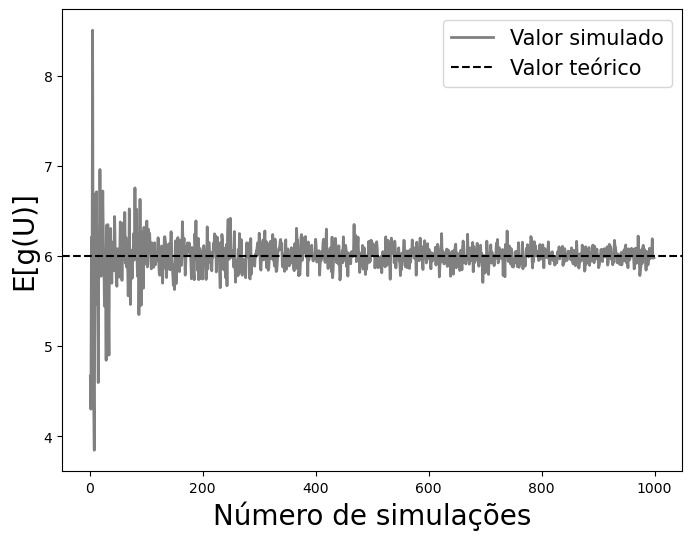

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# função a ser integrada
def g(x,y):
    g = (x**2)*y/3 + (y**2)
    return g

def h(z,w,a, b, c , d):
    h = (b-a)*(d-c)*g(z*(b-a)+a,w*(d-c)+ c)
    return h

valor_teorico = 6
Nmax = 1000 # número máximo de simulações
vtheta = []
vn = []
# intevalos de integração
a = 0; b = 2; c = 1; d = 2
for n in range(1,Nmax):
    theta = 0
    for i in range(n):
        u1 = np.random.uniform(0,1)
        u2 = np.random.uniform(0,1)
        theta = theta + h(u1,u2,a,b,c,d)
    # calcula o valor médio de theta
    theta = theta/n
    vtheta.append(theta)
    vn.append(n)
# mostra os resultados
plt.figure(figsize=(8,6))
plt.plot(vn, vtheta, linestyle='-', color="gray",
         linewidth=2,label = 'Valor simulado')
plt.axhline(y=valor_teorico, color='black',
            linestyle='--', label = 'Valor teórico')
plt.ylabel('E[g(U)]', fontsize=20)
plt.xlabel("Número de simulações", fontsize=20)
plt.legend(fontsize = 15)
plt.savefig("int4.svg")
plt.show(True)

## Simulando variáveis aleatórias

### Variáveis contínuas

#### Modelo exponencial

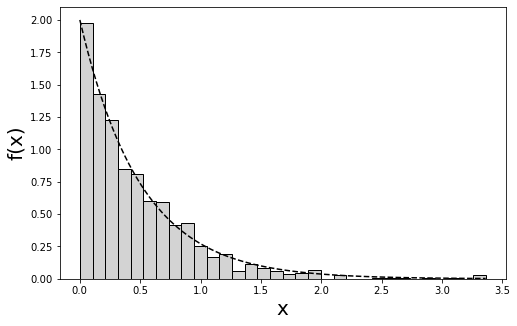

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lbd = 2 # parâmetro do modelo exponencial
n = 1000 # número de valores gerados
X = [] # lista que armazena os valores
for i in range(0,n):
    u = np.random.uniform(0,1)
    x = -(1/lbd)*np.log(1 - u)
    X.append(x)
# mostra a distribuição dos dados gerados
plt.figure(figsize=(8,5))
plt.hist(X, bins='auto', color = 'lightgray',
         histtype='bar', ec='black',density = True)
# mostra a curva teórica
y = np.linspace(0, np.max(X), 100)
f = lbd*np.exp(-lbd*y)
plt.plot(y,f,'--', color = 'black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.savefig('MC-exp.svg')
plt.show(True)

**Exemplo:** Simule a distribuição a seguir usando o método da transformação inversa:
$$
f(x) = \begin{cases}
3x^2, \quad 0 < x  <1,\\
0, \quad \text{caso contrário.}
\end{cases}
$$
A distribuição acumulada de $X$:
$$
F_X(x) = \int_{-\infty}^x 3s^2ds = \int_{0}^x 3s^2ds = x^3.
$$
Logo, a inversa da distribuição acumulada:
$$
\begin{aligned}
x &= F_X^{-1}(u)\\
F(x) &= F_X(F_X^{-1}(u))\\
x^3 &= u\\
x  &= u^{1/3}.
\end{aligned}
$$

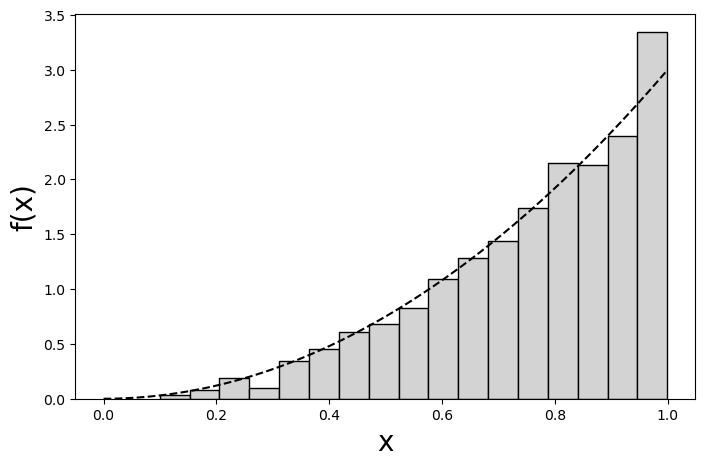

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 1000 # número de valores gerados
X = [] # armazena os valores
for i in range(0,n):
    u = np.random.uniform(0,1)
    x = u**(1/3)
    X.append(x)
# mostra a distribuição dos dados gerados
plt.figure(figsize=(8,5))
plt.hist(X, bins='auto', color = 'lightgray',
         histtype='bar', ec='black',density = True)
# mostra a curva teórica
y = np.linspace(0, np.max(X), 100)
f = 3*y**2
plt.plot(y,f,'--', color = 'black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.show(True)

## Distribuições discretas

#### Distribuição de Bernoulli

In [ ]:
import numpy as np

n = 100 # número de simulações
p = 0.6 # probabilidade de sucesso
X = [] # armaze os valores gerados
for i in range(0,n):
    u = np.random.uniform(0,1)
    if(u <= p):
        X.append(1)
    else:
        X.append(0)
print('Média:', np.mean(X))
print('Variância:', np.var(X))

Média: 0.62
Variância: 0.23560000000000003


**Exemplo:** Simule a distribuição: <br>
X = [1,2,3,4]<br>
P = [0.1, 0.4, 0.2, 0.3]

Valores simulados: [4, 2, 3, 3, 2, 3, 4, 2, 2, 4, 4, 3, 2, 4, 4, 3, 2, 4, 3, 2, 3, 4, 3, 1, 2, 2, 4, 2, 4, 2, 3, 4, 3, 2, 2, 2, 4, 2, 2, 4, 2, 2, 3, 3, 4, 4, 4, 4, 3, 3, 4, 3, 3, 1, 2, 4, 4, 3, 3, 4, 2, 3, 2, 2, 2, 4, 4, 2, 2, 2, 2, 3, 3, 2, 4, 2, 4, 2, 2, 1, 2, 3, 1, 2, 2, 2, 2, 4, 4, 2, 2, 4, 2, 4, 4, 2, 3, 2, 3, 4]
Distribuição teória: [0.1, 0.4, 0.2, 0.3]
Distribuição obtida: [0.04 0.41 0.24 0.31]


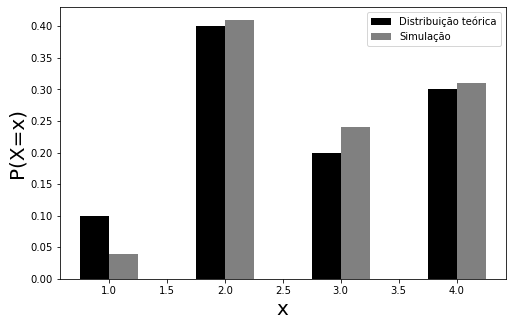

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# função que retorna os valores simulados
def sim_disc(X, P):
    u = np.random.uniform(0,1)
    if u <= P[0]:
        return X[0]
    else:
        for i in range(1,len(P)+1):
            if sum(P[0:i]) < u and sum(P[0:i+1]) > u:
                return X[i]

# distribuição de probabilidade
P = [0.1, 0.4, 0.2, 0.3]
X = [1,2,3,4] # valores da variável aleatória X
n = 100 # número de valores gerados
Xs = [] # armazena os valores simulados
P_sim = np.zeros(len(P))
for i in range(0,n):
    x = sim_disc(X,P) # simula um valor
    Xs.append(x) # armazena em Xs
    # calcula a distribuição simulada
    pos = X.index(x)
    P_sim[pos] = P_sim[pos] + 1
P_sim = P_sim/n
print('Valores simulados:', Xs)
print('Distribuição teória:',P)
print('Distribuição obtida:', P_sim)
# mostra a distribuição dos dados gerados
plt.figure(figsize=(8,5))
plt.bar(np.array(X)-0.125, P, facecolor = 'black',
        width = 0.25, label = 'Distribuição teórica')
plt.bar(np.array(X)+0.125, P_sim, facecolor = 'gray',
        width = 0.25, label = 'Simulação')
# mostra a curva teórica
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(X=x)',fontsize = 20)
plt.legend()
plt.savefig('MC-disc.svg')
plt.show(True)